In [3]:
# ============================================================
# ALZHEIMER'S MRI CLASSIFICATION USING VGG16 TRANSFER LEARNING
# ============================================================

# ------------------------------------------------------------
# 1. Upload the ZIP dataset
# ------------------------------------------------------------
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [4]:
# ------------------------------------------------------------
# 2. Extract ZIP file
# ------------------------------------------------------------
import zipfile
import os

zip_file = list(uploaded.keys())[0]
extract_path = "/content/Alzheimer_Dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Location:", extract_path)

# Show extracted folders
for root, dirs, files in os.walk(extract_path):
    print(root)
    if len(files) > 0:
        print(" Images:", len(files))

Dataset extracted successfully!
Location: /content/Alzheimer_Dataset
/content/Alzheimer_Dataset
/content/Alzheimer_Dataset/Combined Dataset
/content/Alzheimer_Dataset/Combined Dataset/train
/content/Alzheimer_Dataset/Combined Dataset/train/Mild Impairment
 Images: 2560
/content/Alzheimer_Dataset/Combined Dataset/train/Very Mild Impairment
 Images: 2560
/content/Alzheimer_Dataset/Combined Dataset/train/Moderate Impairment
 Images: 2560
/content/Alzheimer_Dataset/Combined Dataset/train/No Impairment
 Images: 2560
/content/Alzheimer_Dataset/Combined Dataset/test
/content/Alzheimer_Dataset/Combined Dataset/test/Mild Impairment
 Images: 179
/content/Alzheimer_Dataset/Combined Dataset/test/Very Mild Impairment
 Images: 448
/content/Alzheimer_Dataset/Combined Dataset/test/Moderate Impairment
 Images: 12
/content/Alzheimer_Dataset/Combined Dataset/test/No Impairment
 Images: 640


In [5]:
# ============================================================
# 3. IMPORT LIBRARIES
# ============================================================
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [6]:
# ============================================================
# 4. DATASET PATHS
# ============================================================
train_path = "/content/Alzheimer_Dataset/Combined Dataset/train"
test_path = "/content/Alzheimer_Dataset/Combined Dataset/test"

In [7]:
# 5. IMAGE PREPROCESSING AND DATA GENERATORS
# ============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 10240 images belonging to 4 classes.
Found 1279 images belonging to 4 classes.


In [8]:
# ============================================================
# 6. NUMBER OF CLASSES
# ============================================================
num_classes = train_data.num_classes

print("Classes:", train_data.class_indices)
print("Number of classes:", num_classes)

Classes: {'Mild Impairment': 0, 'Moderate Impairment': 1, 'No Impairment': 2, 'Very Mild Impairment': 3}
Number of classes: 4


In [10]:
# ============================================================
# 7. LOAD PRE-TRAINED VGG16
# ============================================================
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# ============================================================
# 8. FREEZE VGG16 LAYERS
# ============================================================
for layer in base_model.layers:
    layer.trainable = False

In [12]:
# ============================================================
# 9. ADD CUSTOM CLASSIFICATION HEAD
# ============================================================
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(
    0.5
)(x)

output = Dense(
    num_classes,
    activation='softmax'
)(x)

In [13]:
# ============================================================
# 10. CREATE MODEL
# ============================================================
model = Model(
    inputs=base_model.input,
    outputs=output
)

In [14]:
# ============================================================
# 11. COMPILE MODEL
# ============================================================
model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# ============================================================
# 12. DISPLAY MODEL ARCHITECTURE
# ============================================================
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
# ============================================================
# 13. TRAIN MODEL
# ============================================================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 82s 213ms/step - accuracy: 0.4673 - loss: 1.2038 - val_accuracy: 0.4801 - val_loss: 1.0670
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 58s 180ms/step - accuracy: 0.6237 - loss: 0.8950 - val_accuracy: 0.5293 - val_loss: 0.9352
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 59s 183ms/step - accuracy: 0.6719 - loss: 0.7630 - val_accuracy: 0.5504 - val_loss: 0.9288
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 82s 182ms/step - accuracy: 0.7003 - loss: 0.6929 - val_accuracy: 0.5598 - val_loss: 0.8641
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 59s 184ms/step - accuracy: 0.7109 - loss: 0.6531 - val_accuracy: 0.5731 - val_loss: 0.8515
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 60s 186ms/step - accuracy: 0.7252 - loss: 0.6170 - val_accuracy: 0.5934 - val_loss: 0.8320
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 60s 188ms/step - accuracy: 0.7345 - loss: 0.5937 - val_accuracy: 0.5895 - val_loss: 0.8207
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 60s 189ms/step - accuracy: 0.7435 - loss: 0

In [17]:
# ============================================================
# 14. EVALUATE MODEL
# ============================================================
loss, accuracy = model.evaluate(
    val_data
)

print("\nValidation Accuracy:", accuracy)

40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 166ms/step - accuracy: 0.5911 - loss: 0.8138

Validation Accuracy: 0.5910868048667908


In [18]:
# ============================================================
# 15. PLOT TRAINING AND VALIDATION ACCURACY / LOSS
# ============================================================
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(
    1,
    len(acc) + 1
)

plt.figure(
    figsize=(14, 5)
)

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

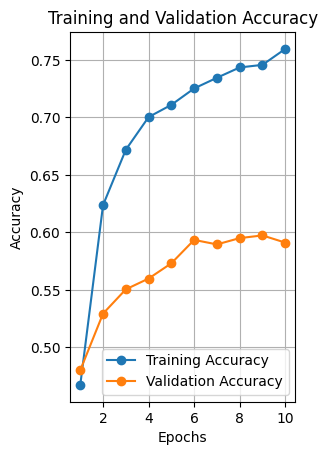

In [19]:
# ------------------------------------------------------------
# Accuracy Plot
# ------------------------------------------------------------
plt.subplot(
    1,
    2,
    1
)

plt.plot(
    epochs_range,
    acc,
    label='Training Accuracy',
    marker='o'
)

plt.plot(
    epochs_range,
    val_acc,
    label='Validation Accuracy',
    marker='o'
)

plt.title(
    'Training and Validation Accuracy'
)

plt.xlabel(
    'Epochs'
)

plt.ylabel(
    'Accuracy'
)

plt.legend(
    loc='lower right'
)

plt.grid(True)

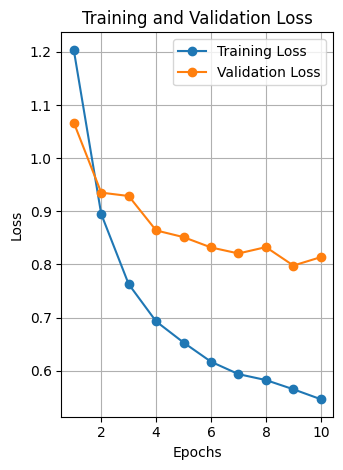

In [20]:
# ------------------------------------------------------------
# Loss Plot
# ------------------------------------------------------------
plt.subplot(
    1,
    2,
    2
)

plt.plot(
    epochs_range,
    loss,
    label='Training Loss',
    marker='o'
)

plt.plot(
    epochs_range,
    val_loss,
    label='Validation Loss',
    marker='o'
)

plt.title(
    'Training and Validation Loss'
)

plt.xlabel(
    'Epochs'
)

plt.ylabel(
    'Loss'
)

plt.legend(
    loc='upper right'
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [21]:
# ============================================================
# 16. CONFUSION MATRIX AND CLASSIFICATION REPORT
# ============================================================
import numpy as np
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [22]:
# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------
val_data.reset()

y_pred_probs = model.predict(
    val_data,
    steps=len(val_data)
)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step


In [23]:
# ------------------------------------------------------------
# Get true labels
# ------------------------------------------------------------
y_true = val_data.classes

class_names = list(
    val_data.class_indices.keys()
)

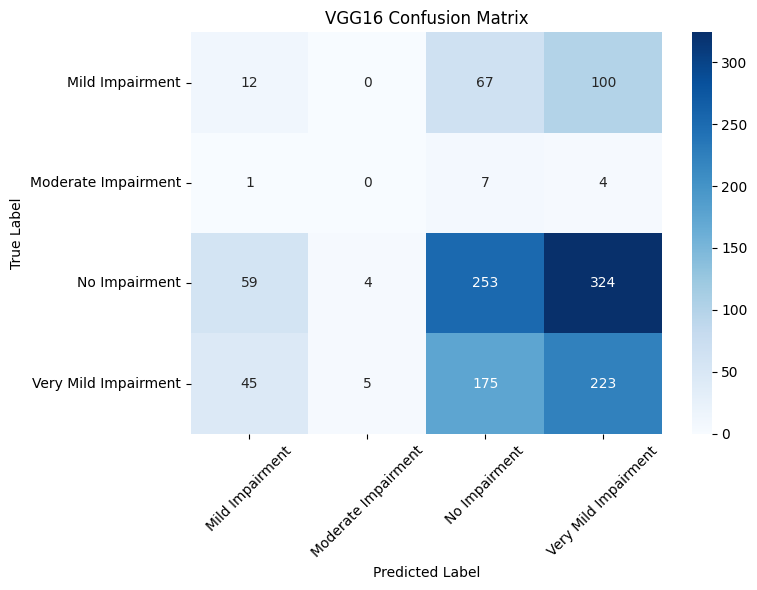

In [25]:
# ============================================================
# 17. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    'VGG16 Confusion Matrix'
)

plt.xlabel(
    'Predicted Label'
)

plt.ylabel(
    'True Label'
)

plt.xticks(
    rotation=45
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [26]:
# ============================================================
# 18. CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


Classification Report:

                      precision    recall  f1-score   support

     Mild Impairment       0.10      0.07      0.08       179
 Moderate Impairment       0.00      0.00      0.00        12
       No Impairment       0.50      0.40      0.44       640
Very Mild Impairment       0.34      0.50      0.41       448

            accuracy                           0.38      1279
           macro avg       0.24      0.24      0.23      1279
        weighted avg       0.39      0.38      0.38      1279

